# Building a Deep Learning Classification Model on the DateFruit Dataset using ANN

In this project, I am working with a dataset that contains various numerical features describing the physical and statistical properties of date fruits.

The goal is to build a multiclass classification model that can accurately classify date fruits into different categories such as DOKOL, SAFAVI, ROTANA, DEGLET, SOGAY, IRAQI, and BERHI.

I start by performing Exploratory Data Analysis (EDA) to understand feature distributions, class balance, and data quality (null values, duplicates, etc.).

After preprocessing the data (including encoding and feature scaling), I implement an Artificial Neural Network (ANN) from scratch using PyTorch to learn patterns from the features and classify the data effectively.

Finally, I evaluate the model’s performance and analyze results to understand its strengths and limitations.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("DateFruit_Dataset.csv")
df.head()

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.908,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.144,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.394,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-93948354560,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.210,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.354,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI


In [3]:
print("----Dataset Overview----")
print("Duplicate Values: \n", df.duplicated().sum()) 
df.describe()

----Dataset Overview----
Duplicate Values: 
 0


,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,SkewRB,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB
count,898.000000,898.000000,898.000000,898.000000,898.000000,898.000000,898.000000,898.000000,898.000000,898.000000,...,898.000000,898.000000,898.000000,898.000000,8.980000e+02,8.980000e+02,8.980000e+02,898.000000,898.000000,898.000000
mean,298295.207127,2057.660953,750.811994,495.872785,0.737468,604.577938,0.981840,303845.592428,0.736267,2.131102,...,0.250518,4.247845,5.110894,3.780928,-3.185021e+10,-2.901860e+10,-2.771876e+10,50.082888,48.805681,48.098393
std,107245.205337,410.012459,144.059326,114.268917,0.088727,119.593888,0.018157,108815.656947,0.053745,17.820778,...,0.632918,2.892357,3.745463,2.049831,2.037241e+10,1.712952e+10,1.484137e+10,16.063125,14.125911,10.813862
min,1987.000000,911.828000,336.722700,2.283200,0.344800,50.298400,0.836600,2257.000000,0.512300,1.065300,...,-1.029100,1.708200,1.607600,1.767200,-1.091224e+11,-9.261697e+10,-8.747177e+10,15.191100,20.524700,22.130000
25%,206948.000000,1726.091500,641.068650,404.684375,0.685625,513.317075,0.978825,210022.750000,0.705875,1.373725,...,-0.196950,2.536625,2.508850,2.577275,-4.429444e+10,-3.894638e+10,-3.564534e+10,38.224425,38.654525,39.250725
50%,319833.000000,2196.345450,791.363400,495.054850,0.754700,638.140950,0.987300,327207.000000,0.746950,1.524150,...,0.135550,3.069800,3.127800,3.080700,-2.826156e+10,-2.620990e+10,-2.392928e+10,53.841300,50.337800,49.614100
75%,382573.000000,2389.716575,858.633750,589.031700,0.802150,697.930525,0.991800,388804.000000,0.775850,1.674750,...,0.593950,4.449850,7.320400,4.283125,-1.460482e+10,-1.433105e+10,-1.660367e+10,63.063350,59.573600,56.666675
max,546063.000000,2811.997100,1222.723000,766.453600,1.000000,833.827900,0.997400,552598.000000,0.856200,535.525700,...,3.092300,26.171100,26.736700,32.249500,-1.627316e+08,-5.627727e+08,-4.370435e+08,79.828900,83.064900,74.104600


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 898 entries, 0 to 897
Data columns (total 35 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AREA           898 non-null    int64  
 1   PERIMETER      898 non-null    float64
 2   MAJOR_AXIS     898 non-null    float64
 3   MINOR_AXIS     898 non-null    float64
 4   ECCENTRICITY   898 non-null    float64
 5   EQDIASQ        898 non-null    float64
 6   SOLIDITY       898 non-null    float64
 7   CONVEX_AREA    898 non-null    int64  
 8   EXTENT         898 non-null    float64
 9   ASPECT_RATIO   898 non-null    float64
 10  ROUNDNESS      898 non-null    float64
 11  COMPACTNESS    898 non-null    float64
 12  SHAPEFACTOR_1  898 non-null    float64
 13  SHAPEFACTOR_2  898 non-null    float64
 14  SHAPEFACTOR_3  898 non-null    float64
 15  SHAPEFACTOR_4  898 non-null    float64
 16  MeanRR         898 non-null    float64
 17  MeanRG         898 non-null    float64
 18  MeanRB    

 **Data is clean with no null and duplicated values**

In [5]:
df["Class"].value_counts()

Class
DOKOL     204
SAFAVI    199
ROTANA    166
DEGLET     98
SOGAY      94
IRAQI      72
BERHI      65
Name: count, dtype: int64

**Classes are slightly imbalance which is manageable**

# Exploratory Data Analysis

### Class Distribution

<Figure size 600x600 with 0 Axes>

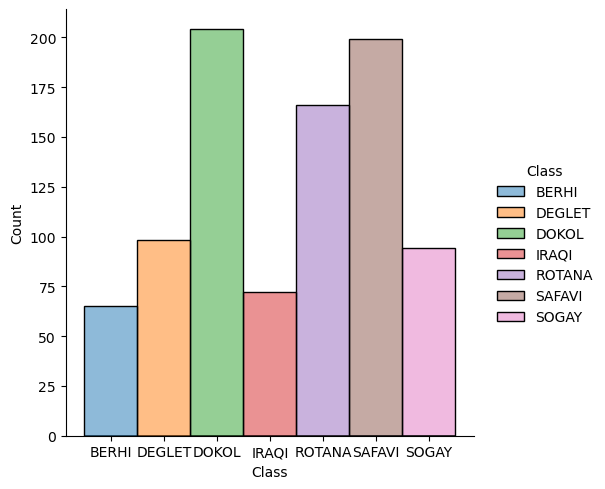

In [6]:
plt.figure(figsize=(6,6))
sns.displot(df, x= "Class", hue="Class")
plt.show()

### Numeric Features Correlation

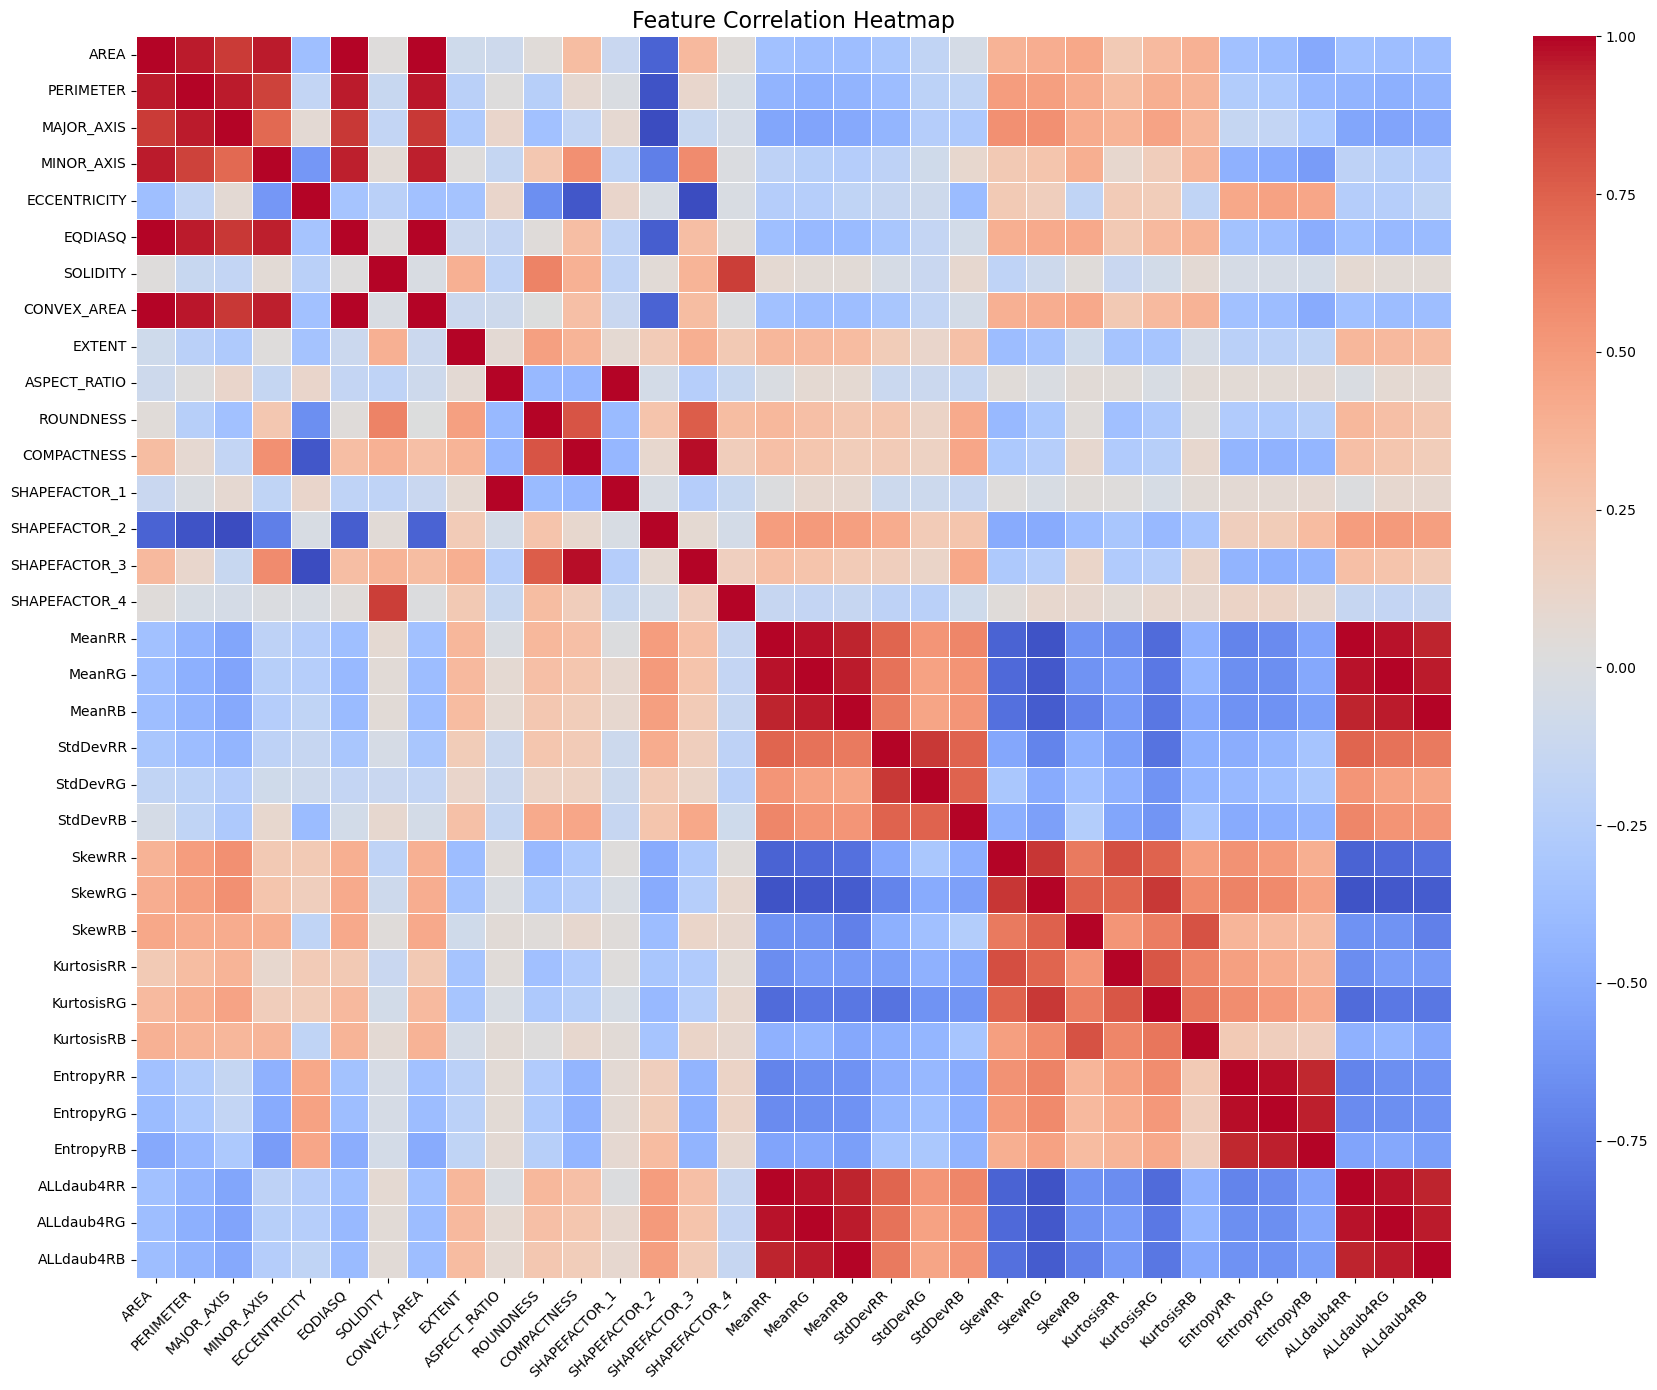

In [7]:
plt.figure(figsize=(18, 14))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Feature Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

### Outliers Analysis 

#### 1. Z-Score Method - identify extreme values based on their distance from the mean.

In [8]:
from scipy import stats
import numpy as np

z = np.abs(stats.zscore(df.drop("Class", axis=1)))
outliers = (z > 3)

outliers.sum(axis=0)

array([ 0,  0,  1,  1, 10,  1, 23,  0,  5,  1,  8,  1,  1, 12,  1, 22,  0,
        0,  0,  2,  5,  2,  2,  1,  7, 16, 10, 17,  8,  8,  8,  0,  0,  0])

#### 2. IQR Method - Since several features in the dataset (such as skewness, kurtosis, and entropy) exhibit non-normal distributions, the IQR method is considered more reliable. This method defines outliers as values falling outside the range

In [9]:
Q1 = df.drop("Class", axis=1).quantile(0.25)
Q3 = df.drop("Class", axis=1).quantile(0.75)
IQR = Q3 - Q1

outliers = ((df.drop("Class", axis=1) < (Q1 - 1.5 * IQR)) | 
            (df.drop("Class", axis=1) > (Q3 + 1.5 * IQR)))

outliers.sum()

AREA               0
PERIMETER          0
MAJOR_AXIS         1
MINOR_AXIS         1
ECCENTRICITY      19
EQDIASQ            1
SOLIDITY          58
CONVEX_AREA        0
EXTENT            13
ASPECT_RATIO      12
ROUNDNESS         35
COMPACTNESS        1
SHAPEFACTOR_1      5
SHAPEFACTOR_2     18
SHAPEFACTOR_3      3
SHAPEFACTOR_4     67
MeanRR             0
MeanRG             0
MeanRB             0
StdDevRR           3
StdDevRG          10
StdDevRB           4
SkewRR            57
SkewRG             0
SkewRB            26
KurtosisRR       130
KurtosisRG        22
KurtosisRB        66
EntropyRR         11
EntropyRG         14
EntropyRB         25
ALLdaub4RR         0
ALLdaub4RG         0
ALLdaub4RB         0
dtype: int64

### Conclusion from EDA -

Through exploratory data analysis, the following key insights are observed:

1. The dataset contains multiple classes with slight class imbalance, which is manageable for model training.
2. The dataset is clean, with no missing values or duplicate entries.
3. Several numerical features show correlation, indicating potential relationships and some degree of feature redundancy.
4. Outliers are present in certain features; however, they are likely due to the natural statistical distribution of the data rather than anomalies. Therefore, feature scaling will be applied instead of removing them.

**Overall, the dataset is well-structured and suitable for building a multiclass classification model using an Artificial Neural Network.**

# Data Preprocessing

### Label Encoding

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Class"] = le.fit_transform(df["Class"])

### Data Split

In [11]:
X = df.drop("Class", axis = 1)
y = df["Class"]

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

### Scaling the Data

In [73]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()

X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test) # to prevent data leakage

### DataLoader and TensorDataset

In [74]:
import torch
import random
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [83]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)


In [84]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size = 32)

## ANN MODEL for Classification

In [85]:
class ANNClassifier(nn.Module):
    def __init__(self):
        super(ANNClassifier, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(X.shape[1], 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 7)
        )


    def forward(self, x):
        return self.model(x)

In [86]:
model = ANNClassifier()
criteria = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001, weight_decay=1e-4)

### Training Model

In [87]:
train_losses = []
val_losses = []
best_val_loss = float("inf")

epochs = 50
for epoch in range(epochs):
# Training loop
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criteria(outputs, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


# Validation loop
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criteria(outputs, yb)
            running_val_loss += loss.item()

    
    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"Epoch: {epoch+1}/{epochs},  Training_loss => {epoch_train_loss:.4f},  Validation_loss => {epoch_val_loss:.4f}")

# Saving best model
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_ann_classifier.pt")


Epoch: 1/50,  Training_loss => 1.7577,  Validation_loss => 1.4710
Epoch: 2/50,  Training_loss => 1.1288,  Validation_loss => 0.8416
Epoch: 3/50,  Training_loss => 0.7165,  Validation_loss => 0.5999
Epoch: 4/50,  Training_loss => 0.5309,  Validation_loss => 0.4520
Epoch: 5/50,  Training_loss => 0.4483,  Validation_loss => 0.3970
Epoch: 6/50,  Training_loss => 0.3834,  Validation_loss => 0.3372
Epoch: 7/50,  Training_loss => 0.3411,  Validation_loss => 0.3054
Epoch: 8/50,  Training_loss => 0.3064,  Validation_loss => 0.2725
Epoch: 9/50,  Training_loss => 0.2862,  Validation_loss => 0.2688
Epoch: 10/50,  Training_loss => 0.2630,  Validation_loss => 0.2406
Epoch: 11/50,  Training_loss => 0.2387,  Validation_loss => 0.2124
Epoch: 12/50,  Training_loss => 0.2323,  Validation_loss => 0.2075
Epoch: 13/50,  Training_loss => 0.2117,  Validation_loss => 0.1953
Epoch: 14/50,  Training_loss => 0.2051,  Validation_loss => 0.2232
Epoch: 15/50,  Training_loss => 0.1994,  Validation_loss => 0.1724
Epoc

### Visualization

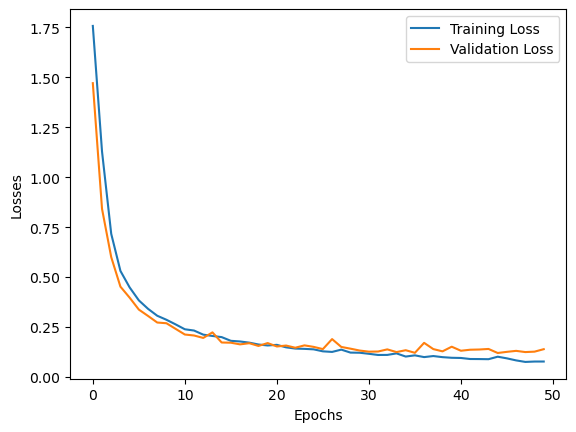

In [88]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

### Loading best model

In [89]:
model.load_state_dict(torch.load("best_ann_classifier.pt"))

<All keys matched successfully>

### Evaluation

In [90]:
from sklearn.metrics import accuracy_score, classification_report

test_preds = torch.argmax(model(X_test_tensor), dim=1)
y_true = y_test_tensor.numpy()
y_pred = test_preds.numpy()
print("Accuracy:", accuracy_score(y_true, y_pred)*100)

report = classification_report(y_true, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report

Accuracy: 95.55555555555556


,precision,recall,f1-score,support
0,0.916667,0.916667,0.916667,12.000000
1,0.888889,0.800000,0.842105,20.000000
2,0.960784,0.980000,0.970297,50.000000
3,0.900000,0.900000,0.900000,10.000000
4,1.000000,1.000000,1.000000,35.000000
5,1.000000,1.000000,1.000000,33.000000
6,0.904762,0.950000,0.926829,20.000000
accuracy,0.955556,0.955556,0.955556,0.955556
macro avg,0.938729,0.935238,0.936557,180.000000
weighted avg,0.955068,0.955556,0.954964,180.000000


### Actual Vs Predicted

In [91]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Predicted Values"])
pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Predicted Values
0,2,2
1,5,5
2,2,2
3,6,6
4,0,0
...,...,...
175,5,5
176,0,0
177,1,1
178,0,0


## Key Insights from Model Training and Evaluation

1. The training and validation loss curves show a consistent decreasing trend, indicating that the model is learning effectively. The validation loss stabilizes around epochs 37–44, suggesting convergence.

2. The small gap between training and validation loss indicates that the model generalizes well and does not suffer from significant overfitting or underfitting.

3. The model achieves an accuracy of approximately **95.5%**, demonstrating strong predictive performance on the test dataset.

4. Minor fluctuations in validation loss in later epochs are observed, which is expected due to mini-batch training and does not indicate instability.

5. Overall, the model exhibits stable learning behavior, good generalization capability, and reliable performance across multiple classes.


## Challenges and Mistakes

During the development of the model, a few key issues were encountered and resolved:

1. **Incorrect Feature Scaling**
   Initially, the test data was scaled using `fit_transform` instead of `transform`, which caused a mismatch between training and testing distributions. This led to extremely high validation loss. The issue was resolved by fitting the scaler only on the training data and applying the same transformation to the test data.

2. **Incorrect Target Tensor Shape**
   The target tensor was initially reshaped using `.view(-1,1)`, which is incompatible with `CrossEntropyLoss`. This caused issues during training. The problem was fixed by keeping the target tensor in the correct shape `(batch_size,)`.

3. **Understanding Evaluation Metrics**
   There was initial confusion in using regression metrics such as MSE and R² for a classification problem. This was corrected by switching to appropriate classification metrics such as accuracy and classification report.

These challenges helped in gaining a deeper understanding of data preprocessing, tensor handling, and proper evaluation techniques in deep learning workflows.
